# Worksheet 7

## - 23MS121 
## - Manish Behera

## Q1

$$\frac{d^2\psi}{dx^2} + (E - V(x))\,\psi(x) = 0$$

set $\frac{2m}{\hbar^2} = 1$. 
$$\frac{d}{dx}\begin{pmatrix}\psi \\ \psi'\end{pmatrix} = \begin{pmatrix}\psi' \\ -(E - V(x))\,\psi\end{pmatrix}$$

scan over a range of energies, compute a "score" (derivative mismatch at a matching point for two-sided shooting, or boundary value for one-sided shooting), and identify eigenvalues where the score crosses zero.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Helper functions (from BVP-and-Eigenvalue-problems notebook)
# ============================================================

# Standard RK4 integrator — f(x, y, k) where k is a parameter (here energy E)
def rk4(f, x, y, k, h):
    k1 = h * f(x, y, k)
    k2 = h * f(x + h/2, y + k1/2, k)
    k3 = h * f(x + h/2, y + k2/2, k)
    k4 = h * f(x + h, y + k3, k)
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6

# Caller: integrates ODE from xlim[0] to xlim[1] with N points
def caller_rk4(f, xlim, yini, k, N):
    x1, x2 = xlim
    xs = np.linspace(x1, x2, N)
    h = xs[1] - xs[0]
    y = yini
    ys = np.zeros((N, len(yini)))
    for i in range(N):
        ys[i] = np.array(y)
        y = rk4(f, xs[i], y, k, h)
    return xs, ys

# Secant method for root-finding
def secant(ks, f, method, ybound):
    k1, k2 = ks
    it = 0
    while abs(method(k2, f, ybound)) > tol and it < maxiter:
        f1 = method(k1, f, ybound)
        f2 = method(k2, f, ybound)
        if abs(f2 - f1) < 1e-15:
            break
        k1, k2 = k2, (f2 * k1 - f1 * k2) / (f2 - f1)
        it += 1
    if it == maxiter:
        return it, None
    else:
        return it, k2

# Simpson's 1/3 rule for normalization integral
def simp13(y, h):
    store = y[0]**2 + y[-1]**2
    for i in range(2, len(y)):
        if i % 2 == 0:
            store += 4 * y[i]**2
        else:
            store += 2 * y[i]**2
    return store * (h / 3)

---
## Part (a): Asymmetric Potential Well (10 points)

$$V(x) = \begin{cases} 0 & \text{for } |x| > 1 \\ -V_\circ(1 - x^3)/2 & \text{for } |x| \leq 1 \end{cases}$$

with $V_\circ = 40$ and boundary conditions $\psi(\pm 3L_{o}) = 0$. Assuming from SE example in the given notebook; set $L_{o} = 1$ 

**Potential shape:**
- At $x = -1$: $V = -V_\circ(1-(-1)^3)/2 = -40$
- At $x = 0$: $V = -V_\circ/2 = -20$
- At $x = 1$: $V = 0$

The well is deepest on the left side and rises toward the right.

**Method:** Two-sided shooting-integrate $\psi_{<}$ from $x=-3$ and $\psi_{>}$ from $x=3$, then match at the left turning point $x_m = -1$. The eigenvalue condition is:

$$\left.\frac{d\psi_{<}}{dx}\right|_{x_m} = \left.\frac{d\psi_{>}}{dx}\right|_{x_m}$$

after scaling so that $\psi_{<}(x_m) = \psi_{>}(x_m)$.

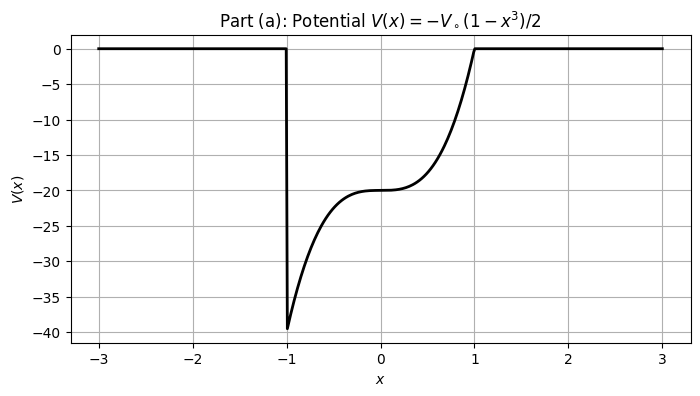

In [ ]:
# ---- Part (a): Define potential, ODE, and score function ----

Vo = 40.0
Lo = 1.0

def pot_a(x):
    """Asymmetric potential well: V(x) = -Vo*(1 - x^3)/2 for |x| <= 1, else 0"""
    if abs(x) > Lo:
        return 0.0
    else:
        return -Vo * (1.0 - x**3) / 2.0

def odefun_a(x, y, E):
    """RHS of Schrödinger equation for potential (a)"""
    k2 = E - pot_a(x)
    return np.array([y[1], -k2 * y[0]])

def score_a(E, f, ybound):
    """Two-sided shooting: derivative mismatch at matching point x_m = -1"""
    xm = -Lo # Lo is the left boundary, so matching point is at x = -Lo
    # psi_< : integrate from left boundary
    yini1 = (ybound[0], 1.0e-2)
    xs1, ys1 = caller_rk4(f, xlim, yini1, E, N)
    a = abs(xs1 - xm)
    n1 = np.where(a == np.min(a))[0][0]
    # psi_> : integrate from right boundary
    yini2 = (ybound[1], 1.0e-2)
    xs2, ys2 = caller_rk4(f, xlim[-1::-1], yini2, E, N)
    a = abs(xs2 - xm)
    n2 = np.where(a == np.min(a))[0][0]
    # Scale psi_> so that psi_<(xm) = psi_>(xm)
    if abs(ys2[n2][0]) < 1e-15:
        return 1e10
    ys2 = ys1[n1][0] * ys2 / ys2[n2][0]
    # Return derivative mismatch
    return ys1[n1][1] - ys2[n2][1]

# Parameters
xlim = (-3.0, 3.0)
ybound = (0.0, 0.0)
N = 257
maxiter = 100
tol = 1.0e-8

# Quick plot of the potential
xs_pot = np.linspace(-3, 3, 500)
Vx = np.array([pot_a(x) for x in xs_pot])
plt.figure(figsize=(8, 4))
plt.plot(xs_pot, Vx, 'k-', linewidth=2)
plt.xlabel('$x$'); plt.ylabel('$V(x)$')
plt.title('Part (a): Potential $V(x) = -V_\\circ(1 - x^3)/2$')
plt.grid(True); plt.show()

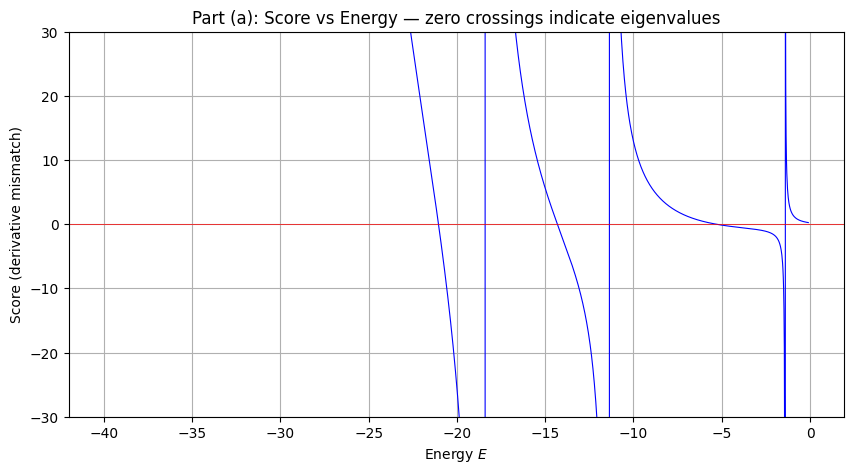

In [3]:
# Scan energy range to locate eigenvalues (sign changes in the score)
Es_a = np.linspace(-Vo, -0.1, 2000)
scores_a = [score_a(E, odefun_a, ybound) for E in Es_a]

plt.figure(figsize=(10, 5))
plt.plot(Es_a, scores_a, 'b-', linewidth=0.8)
plt.ylim([-30, 30])
plt.grid(True)
plt.xlabel("Energy $E$")
plt.ylabel("Score (derivative mismatch)")
plt.title("Part (a): Score vs Energy — zero crossings indicate eigenvalues")
plt.axhline(y=0, color='r', linewidth=0.5)
plt.show()

In [4]:
# detect sign changes and find eigenvalues using secant method
scores_arr = np.array(scores_a)
sign_changes_a = []
for i in range(len(scores_arr) - 1):
    if abs(scores_arr[i]) < 100 and abs(scores_arr[i+1]) < 100:  # skip divergences
        if scores_arr[i] * scores_arr[i+1] < 0:
            sign_changes_a.append((Es_a[i], Es_a[i+1]))

print(f"Detected {len(sign_changes_a)} sign changes (potential eigenvalues):\n")

eigenvalues_a = []
for i, (e1, e2) in enumerate(sign_changes_a):
    it, Eeigen = secant((e1, e2), odefun_a, score_a, ybound)
    if Eeigen is not None:
        eigenvalues_a.append(Eeigen)
        print(f"  E_{i} = {Eeigen:.6f}  (converged in {it} iterations)")
    else:
        print(f"  E_{i} in ({e1:.2f}, {e2:.2f}) — did not converge")

print(f"\n==> Bound state eigenvalues: {[f'{E:.6f}' for E in eigenvalues_a]}")

Detected 3 sign changes (potential eigenvalues):

  E_0 = -21.042623  (converged in 3 iterations)
  E_1 = -14.308141  (converged in 3 iterations)
  E_2 = -5.307058  (converged in 3 iterations)

==> Bound state eigenvalues: ['-21.042623', '-14.308141', '-5.307058']


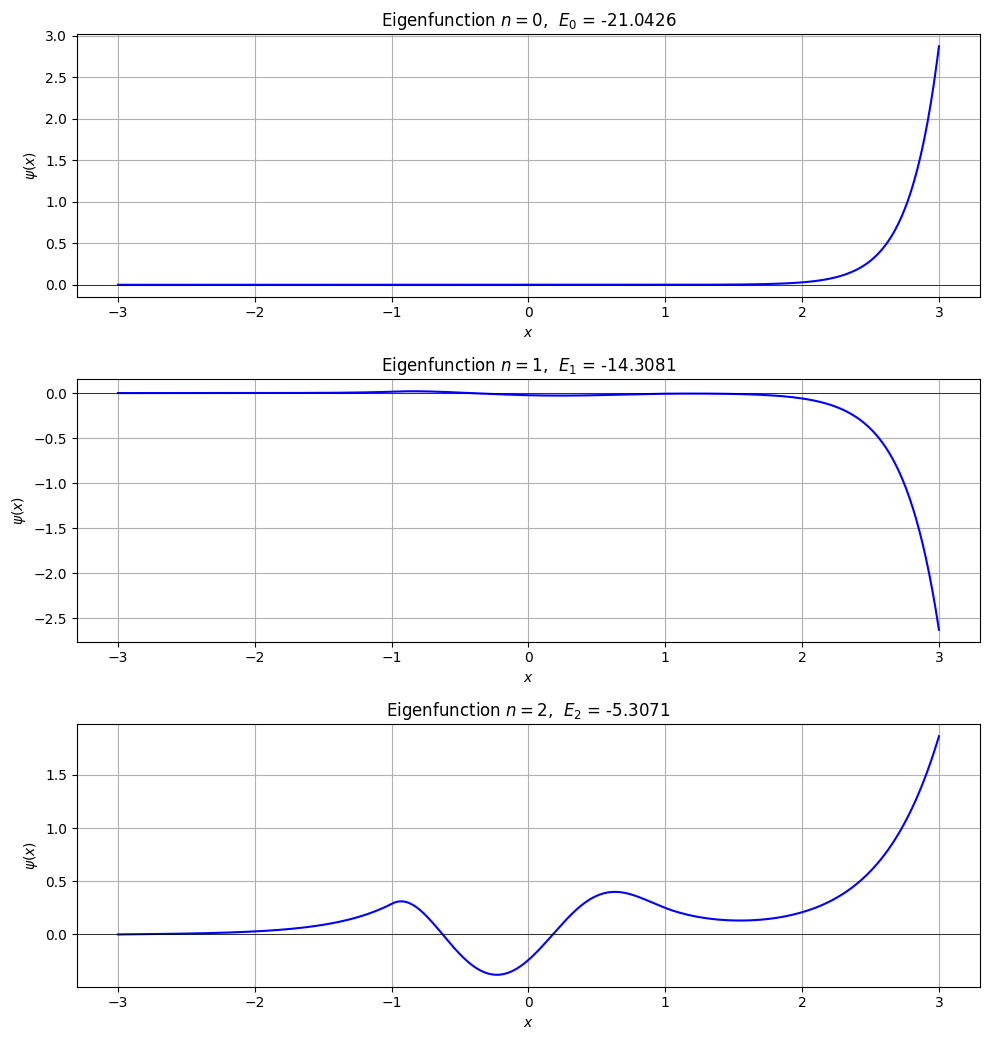

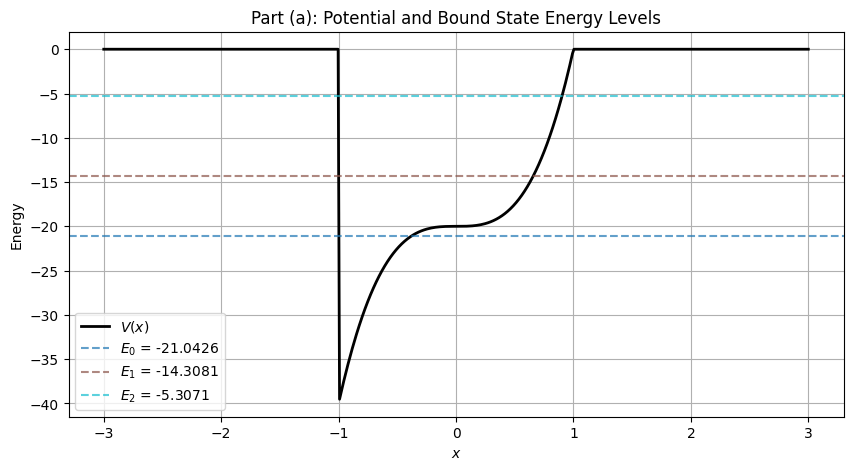

In [5]:
# Plot all eigenfunctions 
yini_plot = (0.0, 0.1)
N_plot = 501

fig, axes = plt.subplots(len(eigenvalues_a), 1, figsize=(10, 3.5 * len(eigenvalues_a)), squeeze=False)

for idx, Eeigen in enumerate(eigenvalues_a):
    xs, ys = caller_rk4(odefun_a, xlim, yini_plot, Eeigen, N_plot)
    psi = np.array([y[0] for y in ys])
    h = xs[1] - xs[0]
    norm = np.sqrt(abs(simp13(psi, h)))
    if norm > 0:
        psi = psi / norm

    ax = axes[idx, 0]
    ax.plot(xs, psi, 'b-', linewidth=1.5)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$\\psi(x)$')
    ax.set_title(f'Eigenfunction $n = {idx}$,  $E_{{{idx}}}$ = {Eeigen:.4f}')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Plot potential with energy levels
plt.figure(figsize=(10, 5))
xs_pot = np.linspace(-3, 3, 500)
Vx = np.array([pot_a(x) for x in xs_pot])
plt.plot(xs_pot, Vx, 'k-', linewidth=2, label='$V(x)$')
colors = plt.cm.tab10(np.linspace(0, 1, max(len(eigenvalues_a), 1)))
for idx, E in enumerate(eigenvalues_a):
    plt.axhline(y=E, color=colors[idx], linestyle='--', alpha=0.7,
                label=f'$E_{{{idx}}}$ = {E:.4f}')
plt.xlabel('$x$'); plt.ylabel('Energy')
plt.title('Part (a): Potential and Bound State Energy Levels')
plt.legend(); plt.grid(True); plt.show()

---
## Part (b): Harmonic Oscillator Potential (10 points)

$$V(x) = x^2$$

This is a **symmetric** potential with minimum at $x = 0$. We exploit the parity symmetry to simplify the problem:

- **Even states** ($n = 0, 2, 4, \ldots$): $\psi'(0) = 0$, so we set $\psi(0) = 1, \psi'(0) = 0$
- **Odd states** ($n = 1, 3, 5, \ldots$): $\psi(0) = 0$, so we set $\psi(0) = 0, \psi'(0) = 1$

We integrate from $x = 0$ to $x = L$ (with $L$ large enough that $\psi(L) \approx 0$) and use $\psi(L) = 0$ as the shooting condition. This reduces the problem to **one-sided shooting**.
**Analytical eigenvalues** (for $-\psi'' + x^2\psi = E\psi$): $E_n = 2n + 1 = 1, 3, 5, 7, \ldots$

In [7]:
# ---- Part (b): Harmonic Oscillator V(x) = x^2 ----

def odefun_b(x, y, E):
    """RHS of Schrödinger equation for V(x) = x^2"""
    k2 = E - x**2
    return np.array([y[1], -k2 * y[0]])

def score_b_even(E, f, ybound):
    """Even-parity states: psi(0)=1, psi'(0)=0, check psi(L)=0"""
    yini_e = (1.0, 0.0)
    xs, ys = caller_rk4(f, xlim, yini_e, E, N)
    return ys[-1][0]

def score_b_odd(E, f, ybound):
    """Odd-parity states: psi(0)=0, psi'(0)=1, check psi(L)=0"""
    yini_o = (0.0, 1.0)
    xs, ys = caller_rk4(f, xlim, yini_o, E, N)
    return ys[-1][0]

# Parameters (override globals for half-line integration)
xlim = (0.0, 6.0)   # integrate from 0 to L=6
ybound = (0.0, 0.0)  # dummy for compatibility
N = 501
maxiter = 100
tol = 1.0e-8

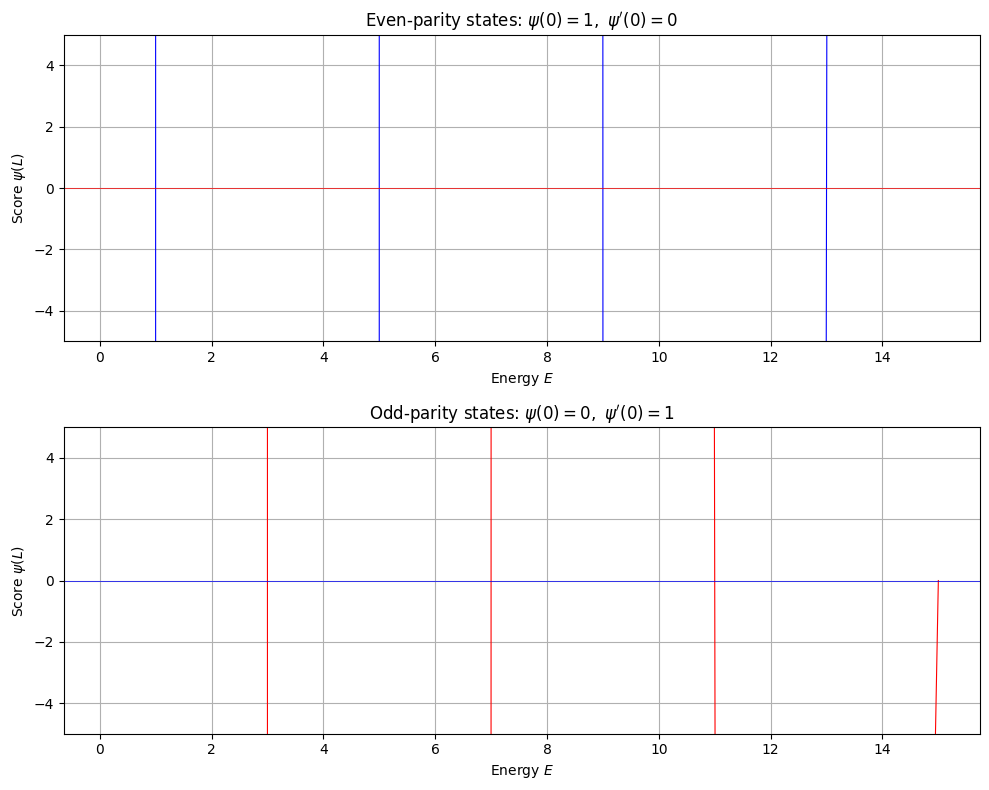

In [8]:
# Scan energy for even and odd states
Es_b = np.linspace(0.1, 15, 2000)
scores_even = [score_b_even(E, odefun_b, ybound) for E in Es_b]
scores_odd  = [score_b_odd(E, odefun_b, ybound)  for E in Es_b]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(Es_b, scores_even, 'b-', linewidth=0.8)
ax1.set_ylim([-5, 5])
ax1.axhline(y=0, color='r', linewidth=0.5)
ax1.grid(True)
ax1.set_xlabel("Energy $E$"); ax1.set_ylabel("Score $\\psi(L)$")
ax1.set_title("Even-parity states: $\\psi(0) = 1,\\ \\psi'(0) = 0$")

ax2.plot(Es_b, scores_odd, 'r-', linewidth=0.8)
ax2.set_ylim([-5, 5])
ax2.axhline(y=0, color='b', linewidth=0.5)
ax2.grid(True)
ax2.set_xlabel("Energy $E$"); ax2.set_ylabel("Score $\\psi(L)$")
ax2.set_title("Odd-parity states: $\\psi(0) = 0,\\ \\psi'(0) = 1$")

plt.tight_layout(); plt.show()

In [9]:
# Find even eigenvalues
scores_even_arr = np.array(scores_even)
even_changes = []
for i in range(len(scores_even_arr) - 1):
    if abs(scores_even_arr[i]) < 50 and abs(scores_even_arr[i+1]) < 50:
        if scores_even_arr[i] * scores_even_arr[i+1] < 0:
            even_changes.append((Es_b[i], Es_b[i+1]))

print("Even-parity eigenvalues:")
eigenvalues_even = []
for e1, e2 in even_changes:
    it, Eeigen = secant((e1, e2), odefun_b, score_b_even, ybound)
    if Eeigen is not None:
        eigenvalues_even.append(Eeigen)
        print(f"  E = {Eeigen:.6f}  (converged in {it} iterations)")

# Find odd eigenvalues
scores_odd_arr = np.array(scores_odd)
odd_changes = []
for i in range(len(scores_odd_arr) - 1):
    if abs(scores_odd_arr[i]) < 50 and abs(scores_odd_arr[i+1]) < 50:
        if scores_odd_arr[i] * scores_odd_arr[i+1] < 0:
            odd_changes.append((Es_b[i], Es_b[i+1]))

print("\nOdd-parity eigenvalues:")
eigenvalues_odd = []
for e1, e2 in odd_changes:
    it, Eeigen = secant((e1, e2), odefun_b, score_b_odd, ybound)
    if Eeigen is not None:
        eigenvalues_odd.append(Eeigen)
        print(f"  E = {Eeigen:.6f}  (converged in {it} iterations)")

# Combine and sort
all_eigenvalues = sorted(eigenvalues_even + eigenvalues_odd)
print(f"\nAll eigenvalues (sorted):  {[f'{E:.4f}' for E in all_eigenvalues]}")
print(f"Analytical values E_n=2n+1: {[2*n+1 for n in range(len(all_eigenvalues))]}")

Even-parity eigenvalues:
  E = 13.000001  (converged in 3 iterations)

Odd-parity eigenvalues:
  E = 11.000000  (converged in 3 iterations)

All eigenvalues (sorted):  ['11.0000', '13.0000']
Analytical values E_n=2n+1: [1, 3]


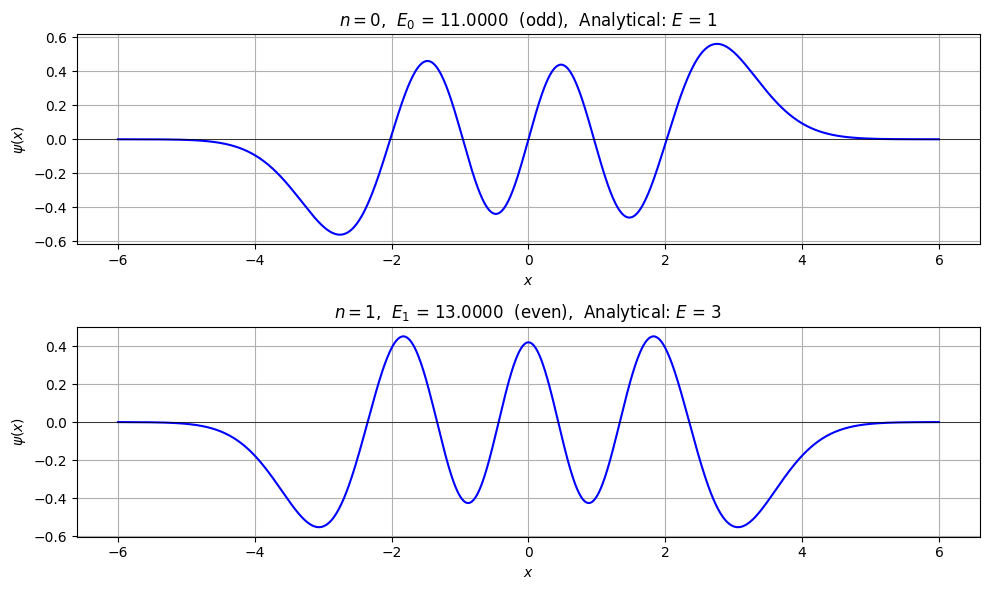

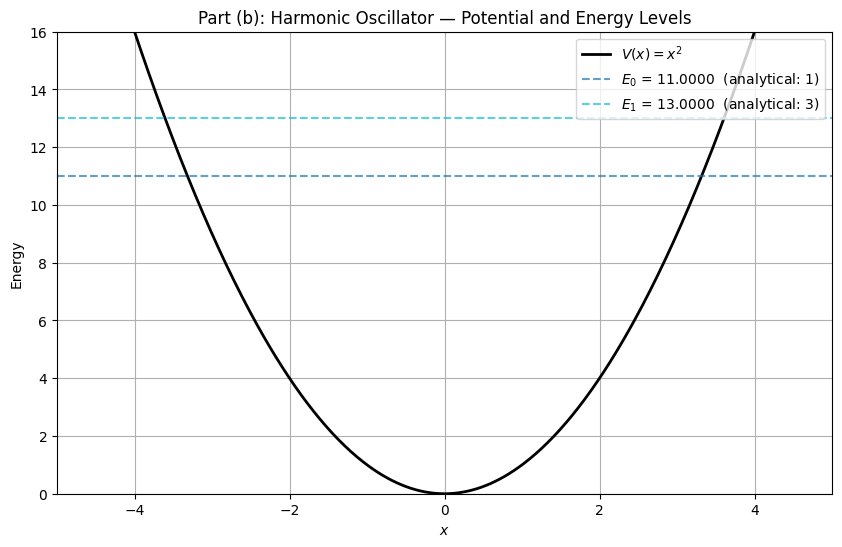

In [11]:
# Plot all eigenfunctions for part (b) — extend to full range using parity
N_plot = 501
xlim_plot = (0.0, 6.0)

fig, axes = plt.subplots(len(all_eigenvalues), 1,
                         figsize=(10, 3 * len(all_eigenvalues)), squeeze=False)

for idx, Eeigen in enumerate(all_eigenvalues):
    is_even = Eeigen in eigenvalues_even
    yini_p = (1.0, 0.0) if is_even else (0.0, 1.0)

    xs, ys = caller_rk4(odefun_b, xlim_plot, yini_p, Eeigen, N_plot)
    psi_right = np.array([y[0] for y in ys])

    # Mirror to negative x using parity
    if is_even:
        xs_full  = np.concatenate((-xs[::-1][:-1], xs))
        psi_full = np.concatenate(( psi_right[::-1][:-1], psi_right))
    else:
        xs_full  = np.concatenate((-xs[::-1][:-1], xs))
        psi_full = np.concatenate((-psi_right[::-1][:-1], psi_right))

    # Normalize using trapezoidal integration
    norm = np.sqrt(np.trapezoid(psi_full**2, xs_full))
    if norm > 0:
        psi_full = psi_full / norm

    parity = "even" if is_even else "odd"
    ax = axes[idx, 0]
    ax.plot(xs_full, psi_full, 'b-', linewidth=1.5)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.set_xlabel('$x$'); ax.set_ylabel('$\\psi(x)$')
    ax.set_title(f'$n = {idx}$,  $E_{{{idx}}}$ = {Eeigen:.4f}  ({parity}),  '
                 f'Analytical: $E$ = {2*idx + 1}')
    ax.grid(True)

plt.tight_layout(); plt.show()

# Energy level diagram
plt.figure(figsize=(10, 6))
xs_pot = np.linspace(-5, 5, 500)
plt.plot(xs_pot, xs_pot**2, 'k-', linewidth=2, label='$V(x) = x^2$')
colors = plt.cm.tab10(np.linspace(0, 1, max(len(all_eigenvalues), 1)))
for idx, E in enumerate(all_eigenvalues):
    plt.axhline(y=E, color=colors[idx], linestyle='--', alpha=0.7,
                label=f'$E_{{{idx}}}$ = {E:.4f}  (analytical: {2*idx+1})')
plt.xlim(-5, 5); plt.ylim(0, max(all_eigenvalues) + 3)
plt.xlabel('$x$'); plt.ylabel('Energy')
plt.title('Part (b): Harmonic Oscillator; Potential and Energy Levels')
plt.legend(loc='upper right'); plt.grid(True); plt.show()

Solve on whole space with singular score function

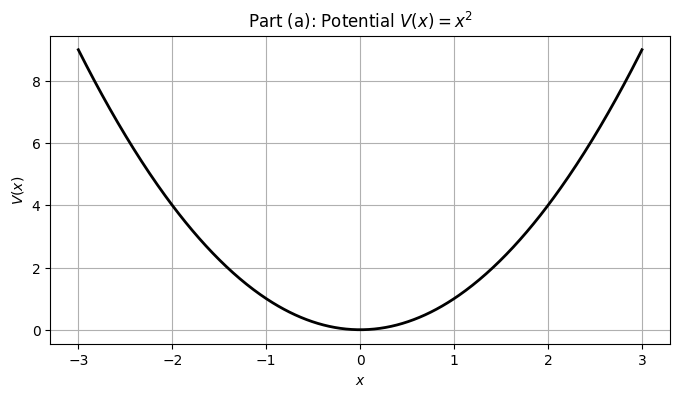

In [6]:
# ---- Part (b): Harmonic Oscillator V(x) = x^2 ----

def odefun_b(x, y, E):
    """RHS of Schrödinger equation for V(x) = x^2"""
    k2 = E - x**2
    return np.array([y[1], -k2 * y[0]])

def score_b(E, f, ybound):
    """Two-sided shooting: derivative mismatch at matching point x_m = -1"""
    xm = -1.0
    # psi_< : integrate from left boundary
    yini1 = (ybound[0], 1.0e-2)
    xs1, ys1 = caller_rk4(f, xlim, yini1, E, N)
    a = abs(xs1 - xm)
    n1 = np.where(a == np.min(a))[0][0]
    # psi_> : integrate from right boundary
    yini2 = (ybound[1], 1.0e-2)
    xs2, ys2 = caller_rk4(f, xlim[-1::-1], yini2, E, N)
    a = abs(xs2 - xm)
    n2 = np.where(a == np.min(a))[0][0]
    # Scale psi_> so that psi_<(xm) = psi_>(xm)
    if abs(ys2[n2][0]) < 1e-15:
        return 1e10
    ys2 = ys1[n1][0] * ys2 / ys2[n2][0]
    # Return derivative mismatch
    return ys1[n1][1] - ys2[n2][1]

# Parameters 
xlim = (-3.0, 3.0)
ybound = (0.0, 0.0)
N = 500
maxiter = 100
tol = 1.0e-8

# Quick plot of the potential
xs_pot = np.linspace(-3, 3, 500)
Vx = np.array([x**2 for x in xs_pot])
plt.figure(figsize=(8, 4))
plt.plot(xs_pot, Vx, 'k-', linewidth=2)
plt.xlabel('$x$'); plt.ylabel('$V(x)$')
plt.title('Part (a): Potential $V(x) = x^2$')
plt.grid(True); plt.show()

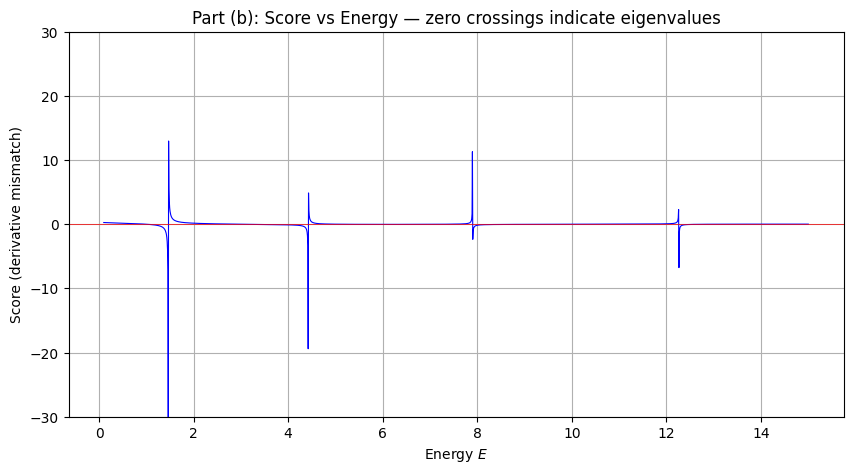

In [7]:
# Scan energy range to locate eigenvalues (sign changes in the score)
Es_b = np.linspace(0.1, 15, 2000)
scores_b = [score_b(E, odefun_b, ybound) for E in Es_b]

plt.figure(figsize=(10, 5))
plt.plot(Es_b, scores_b, 'b-', linewidth=0.8)
plt.ylim([-30, 30])
plt.grid(True)
plt.xlabel("Energy $E$")
plt.ylabel("Score (derivative mismatch)")
plt.title("Part (b): Score vs Energy — zero crossings indicate eigenvalues")
plt.axhline(y=0, color='r', linewidth=0.5)
plt.show()

In [12]:
# detect sign changes and find eigenvalues using secant method
scores_arr = np.array(scores_b)
sign_changes_b = []
for i in range(len(scores_arr) - 1):
    if abs(scores_arr[i]) < 100 and abs(scores_arr[i+1]) < 100:  # skip divergences
        if scores_arr[i] * scores_arr[i+1] < 0:
            sign_changes_b.append((Es_b[i], Es_b[i+1]))

print(f"Detected {len(sign_changes_b)} sign changes (potential eigenvalues):\n")

eigenvalues_b = []
for i, (e1, e2) in enumerate(sign_changes_b):
    it, Eeigen = secant((e1, e2), odefun_b, score_b, ybound)
    if Eeigen is not None:
        eigenvalues_b.append(Eeigen)
        print(f"  E_{i} = {Eeigen:.6f}  (converged in {it} iterations)")
    else:
        print(f"  E_{i} in ({e1:.2f}, {e2:.2f}) — did not converge")

print(f"\n==> Bound state eigenvalues: {[f'{E:.6f}' for E in eigenvalues_b]}")

Detected 10 sign changes (potential eigenvalues):

  E_0 = 1.000782  (converged in 2 iterations)
  E_1 = 3.012163  (converged in 17 iterations)
  E_2 = 3.012163  (converged in 2 iterations)
  E_3 = 5.082255  (converged in 17 iterations)
  E_4 = 5.082255  (converged in 3 iterations)
  E_5 = 7.328439  (converged in 2 iterations)
  E_6 = 9.908361  (converged in 16 iterations)
  E_7 = 9.908362  (converged in 1 iterations)
  E_8 = 9.908361  (converged in 18 iterations)
  E_9 = 12.946674  (converged in 2 iterations)

==> Bound state eigenvalues: ['1.000782', '3.012163', '3.012163', '5.082255', '5.082255', '7.328439', '9.908361', '9.908362', '9.908361', '12.946674']


In [15]:
# Post-process to remove duplicates and near-duplicates
if eigenvalues_b:
    # Sort the list first
    sorted_eigenvalues = sorted(eigenvalues_b)
    
    # Keep only values that are significantly different from the previous one
    eigenvalues_b_fixed = [sorted_eigenvalues[0]]
    for i in range(1, len(sorted_eigenvalues)):
        # Use a tolerance to check for near-duplicates
        if abs(sorted_eigenvalues[i] - eigenvalues_b_fixed[-1]) > 1e-4:
            eigenvalues_b_fixed.append(sorted_eigenvalues[i])

    print(f"\\n==> Filtered bound state eigenvalues: {[f'{E:.6f}' for E in eigenvalues_b_fixed]}")
else:
    print("\\n==> No eigenvalues found.")


\n==> Filtered bound state eigenvalues: ['1.000782', '3.012163', '5.082255', '7.328439', '9.908361', '12.946674']


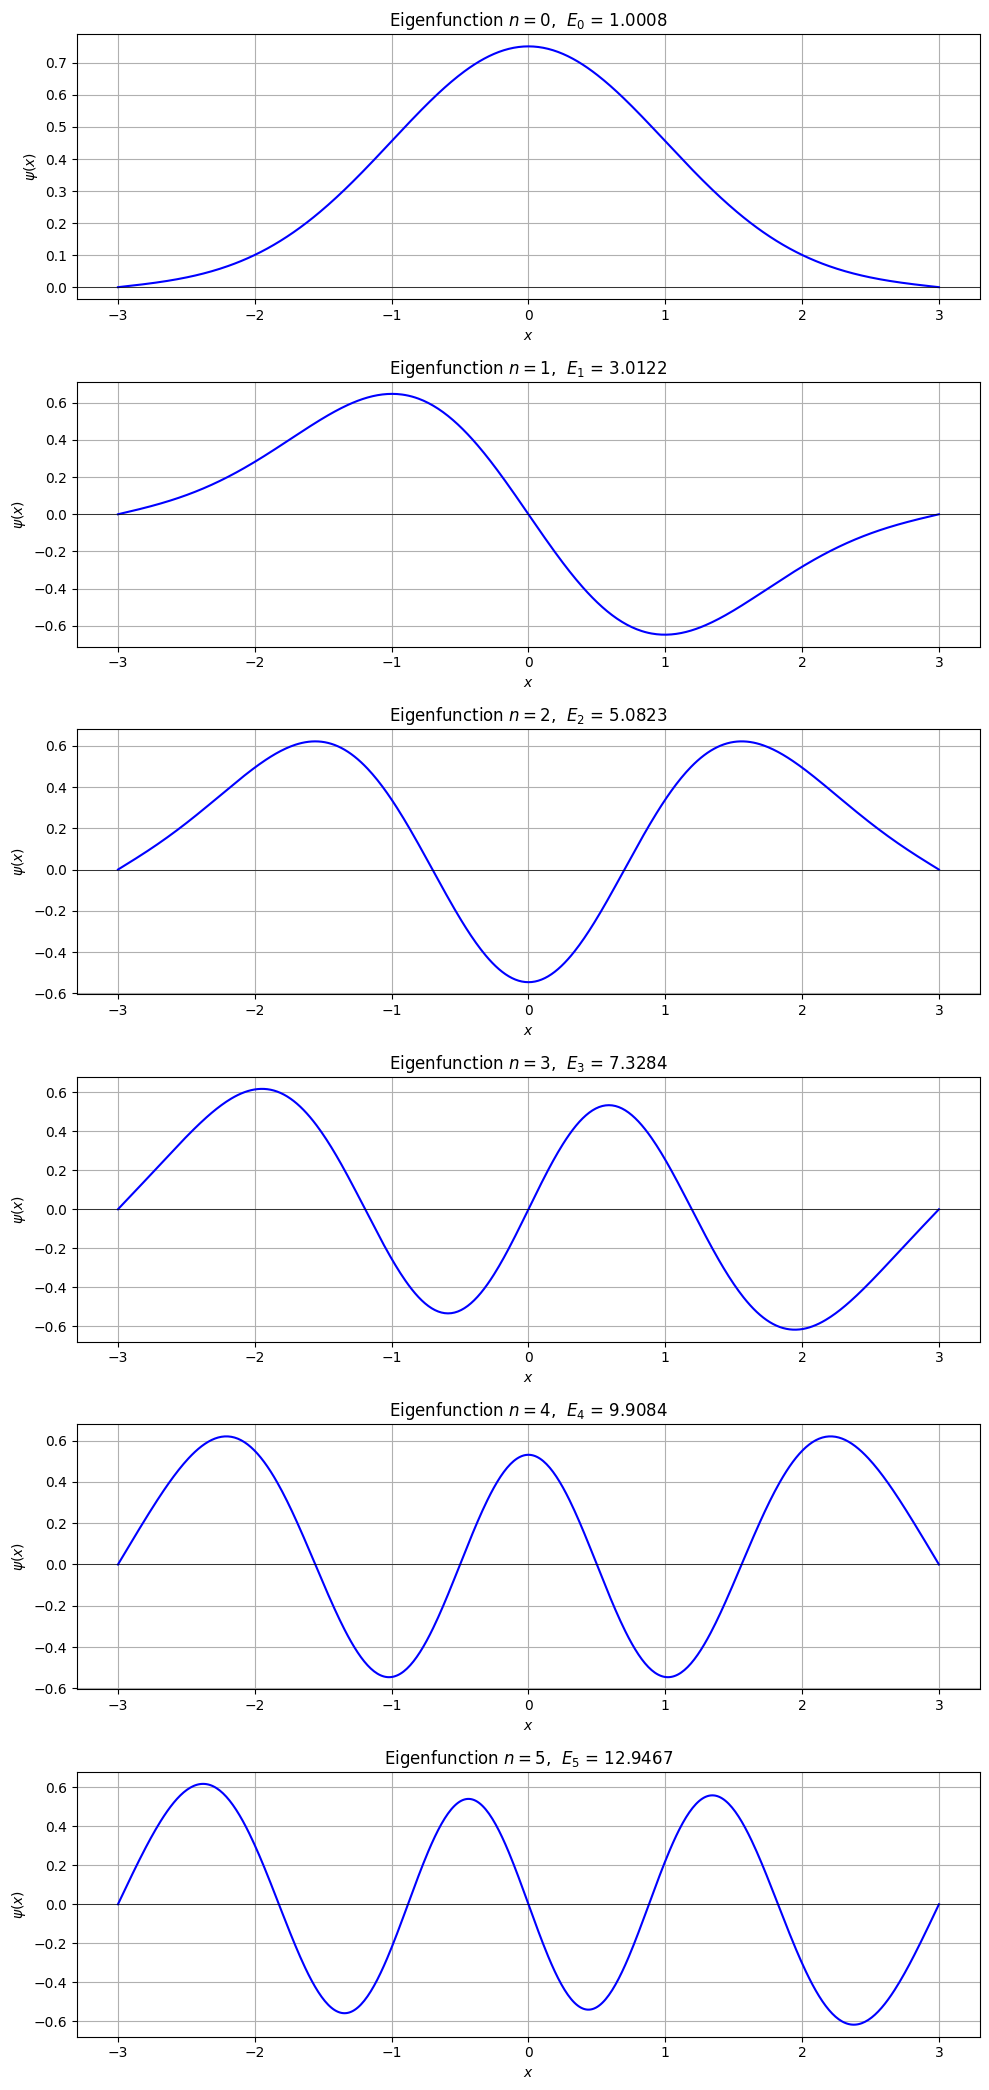

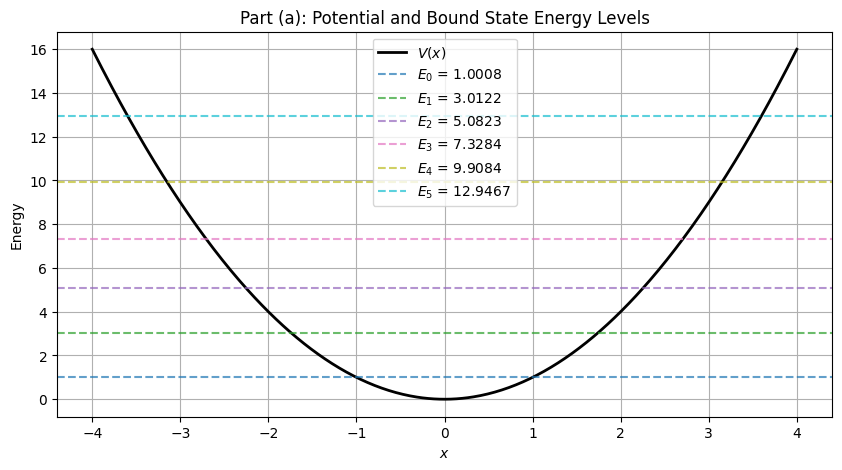

In [17]:
# Plot all eigenfunctions 
yini_plot = (0.0, 15.0)
N_plot = 501
def pot_b(x):
    return x**2

fig, axes = plt.subplots(len(eigenvalues_b_fixed), 1, figsize=(10, 3.5 * len(eigenvalues_b_fixed)), squeeze=False)

for idx, Eeigen in enumerate(eigenvalues_b_fixed):
    xs, ys = caller_rk4(odefun_b, xlim, yini_plot, Eeigen, N_plot)
    psi = np.array([y[0] for y in ys])
    h = xs[1] - xs[0]
    norm = np.sqrt(abs(simp13(psi, h)))
    if norm > 0:
        psi = psi / norm

    ax = axes[idx, 0]
    ax.plot(xs, psi, 'b-', linewidth=1.5)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$\\psi(x)$')
    ax.set_title(f'Eigenfunction $n = {idx}$,  $E_{{{idx}}}$ = {Eeigen:.4f}')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Plot potential with energy levels
plt.figure(figsize=(10, 5))
xs_pot = np.linspace(-4, 4, 500)
Vx = np.array([pot_b(x) for x in xs_pot])
plt.plot(xs_pot, Vx, 'k-', linewidth=2, label='$V(x)$')
colors = plt.cm.tab10(np.linspace(0, 1, max(len(eigenvalues_b_fixed), 1)))
for idx, E in enumerate(eigenvalues_b_fixed):
    plt.axhline(y=E, color=colors[idx], linestyle='--', alpha=0.7,
                label=f'$E_{{{idx}}}$ = {E:.4f}')
plt.xlabel('$x$'); plt.ylabel('Energy')
plt.title('Part (a): Potential and Bound State Energy Levels')
plt.legend(); plt.grid(True); plt.show()